In [1]:
import sys
sys.version

'3.10.4 (main, Mar 31 2022, 03:37:37) [Clang 12.0.0 ]'

In [2]:
import numpy as np
import networkx as nx
import scipy

Schur complement example

Let $L$ be the Laplacian matrix of a graph $G=(V,E)$. Let $\{T,N\}$ be a partition of $V$ into terminal and non terminal vertices. Then, the Laplacian matrix of $L$ can be expressed as follow
$$
L=\begin{bmatrix}
        L_N & L_M\\
        L_M^T & L_T
        \end{bmatrix}.
$$
The Schur complement onto $T\subset V$ is defined as follow
$$
L_{SC}=L_T-L_M^TL_N^{-1}L_M
$$

In [ ]:
edge_list = [(1,2),(1,3),(1,4),(4,5), (2,6),(3,4),(5,6)]
G = nx.Graph(edge_list)

In [ ]:
G.nodes()

In [ ]:
nx.draw(G, with_labels=True)

In [ ]:
L = nx.laplacian_matrix(G).toarray()
L

Now, lets define $T=\{4,5,6\}$ and $N=\{1,2,3\}$. Then, the corresponding submatrices $L_T$, $L_N$ and $L_M$ are

In [ ]:
LT = L[3:,3:]
LT

In [ ]:
LN = L[:3,:3]
LN

In [ ]:
LM = L[:3,3:]
LM

In order to compute $L_{SC}$ we need to compute the inverse of $L_N$, $L_N^{-1}$

In [ ]:
LN_1 = np.linalg.inv(LN)
LN_1

In [ ]:
np.outer(LN[:,0],(LN_1[:,0]))

In [ ]:
LM.transpose().dot(LN_1[:,2])

Now, the Schur complement of $L$ is

In [ ]:
LSC = LT-LM.transpose().dot(LN_1.dot(LM))
LSC

We now want to add a vertex from the non terminal set $N$ to the terminal set $T$ and update the Schur complement. In order to do that we will use the following claim.

__Claim 1.__ Let $u\in N$ be a non terminal vertex and suppose all vertices in $N-\{u\}$ have been previously deleted from $G$. Then $L_M^TL_N^{-1}(:,u)$ in the $v$-th entry is the factor by which each edge $e=(v,w)$ for $w\in T$ change after deleting vertex $u$ from $G$.

In [ ]:
LM.transpose().dot(LN_1[:,0])

In [ ]:
LM.transpose().dot(LN_1[:,1])

In [ ]:
LM.transpose().dot(LN_1[:,2])

In [ ]:
LM.transpose().dot(LN_1[:,0])+LM.transpose().dot(LN_1[:,1])+LM.transpose().dot(LN_1[:,2])

In [ ]:
-7/5,-1/5

In [ ]:
8/5

In [ ]:
LN[:,2].dot(LN_1[:,1])

In [ ]:
LN[2,:-1]

In [ ]:
LN_1[:-1,:-1].dot(LN[2,:-1])

In [ ]:
LN_1.dot(LN[2,:])

In [ ]:
np.linalg.inv(LN[:-1,:-1]).dot(LN[2,:-1])

In [ ]:
LN[2,:-1].dot(np.linalg.inv(LN[:-1,:-1]).dot(LN[2,:-1]))

In [ ]:
L[2,2]-LN[2,:-1].dot(np.linalg.inv(LN[:-1,:-1]).dot(LN[2,:-1]))

$\frac{8}{5}=1.6$

Multiply $L_N^{-1} \begin{bmatrix}u_N \\ 0\end{bmatrix}=x$ where $x=\begin{bmatrix} x'\\x_N \end{bmatrix}$. In this case $u_N$ is the last column of $L_N$ without the degree.

In [ ]:
p = LN[:,-1].copy()
p

In [ ]:
p[-1] = 0
p

In [ ]:
x = LN_1.dot(p)
x

Now, $L_{N'}^{-1}u_N=x'/(1-x_N)$ 

In [ ]:
x[:-1]/(1-x[-1])

In [ ]:
L[2,2]-LN[2,:-1].dot(x[:-1]/(1-x[-1]))

Example

In [ ]:
A = np.array([[4,-1,-1],[-1,1,0],[-1,0,1]])
A

In [ ]:
A_1 = np.linalg.inv(A)
A_1

In [ ]:
B = np.array([[-1,0,0],[-1,0,0]])
B

In [ ]:
A_1[:,2].dot(B.transpose())

Woodbury formula for updating the inverse of a matrix. Let $A$ be an $n\times n$ matrix with inverse $A^{-1}$. Let $C, U$ and $V$ matrices such that $C$ is $k\times k$, $U$ is $n\times k$ and $V$ is $k\times n$. Then
$$
(A+UCV)^{-1}=A^{-1}-A^{-1}U(C^{-1}+VA^{-1}U)^{-1}VA^{-1}
$$

In [ ]:
A = np.array([[3,-1,-1],[-1,2,0],[-1,0,2]])
A_1 = np.array([[1/2,1/4,1/4],[1/4,5/8,1/8],[1/4,1/8,5/8]])
U = np.array([[0,-1],[0,0],[1,1]])
V = np.array([[-1, 0, 1],[0,0,1]])
I = np.identity(2)

In [ ]:
A

In [ ]:
A_1

In [ ]:
A[:-1,:-1]

In [ ]:
np.outer(A[0,1:], A[0,1:])/A[1,1]

In [ ]:
A[:-1,:-1]-np.outer(A[0,1:], A[0,1:])/A[1,1]

In [ ]:
np.linalg.inv(A[:-1,:-1])

In [ ]:
U.dot(V)

In [ ]:
B = I + V.dot(A_1.dot(U))
B

In [ ]:
B_1 = np.linalg.inv(B)

In [ ]:
C = A_1 - A_1.dot(U.dot(B_1.dot(V.dot(A_1))))
C

We want the inverse of this matrix

In [ ]:
D = A - U.dot(V)
D

In [ ]:
np.linalg.inv(D[:-1,:-1])

In [ ]:
D_1

In [ ]:
C.dot(D)

In [ ]:
D

Suppose we have
$$
A = \begin{bmatrix}
    A_{11}&A_{12}\\
    A_{21}&A_{22}
    \end{bmatrix}=
    \begin{bmatrix}
    L_{11}&0\\
    L_{21}&L_{22}
    \end{bmatrix}
    \begin{bmatrix}
    L_{11}^T&L_{21}^T\\
    0&L_{22}^T
    \end{bmatrix}
    =LL^T
$$

and a matrix $B$ such that $BA=AB=I$ with the following decomposition
$$
B = \begin{bmatrix}
    B_{11}&B_{12}\\
    B_{21}&B_{22}
    \end{bmatrix}
$$

Then the inverse of $B_{22}$ is given by
$$
B_{22}^{-1}=A_{22}-L_{21}L_{21}^T
$$

In [ ]:
import numpy as np

In [ ]:
A = np.array([[3,-1,-1],[-1,1,0],[-1,0,3]])
A

In [ ]:
A_1 = np.linalg.inv(A)
A_1

In [ ]:
LM = np.array([[-1,0],[0,0],[-1,-1]])
LM

In [ ]:
LM.transpose().dot(A_1[:,2])

Example on random graph on 5 vertices

In [ ]:
G = nx.random_graphs.star_graph(5)
nx.draw(G, with_labels=True)

In [ ]:
L = nx.laplacian_matrix(G).toarray()
L

Now, we are gonna delete 3 and 4 vertices. In order to do that we are gonna make a copy of L

In [ ]:
L1 = L.copy()
L2 = L.copy()

First we will construct a Schur complement of 3 vertices (the last 3) with L1

In [ ]:
LT1 = L1[3:,3:]
LT1

In [ ]:
LN1 = L1[:3,:3]
LN1

In [ ]:
LM1 = L1[:3,3:]
LM1

In [ ]:
LN1_1 = np.linalg.inv(LN1)
LN1_1

In [ ]:
LSC1 = LT1-LM1.transpose().dot(LN1_1.dot(LM1))
LSC1

Now we are going to construct the Schur complement on 4 vertices

In [ ]:
LT2 = L2[2:,2:]
LT2

In [ ]:
LN2 = L2[:2,:2]
LN2

In [ ]:
LN2_1 = np.linalg.inv(LN2)
LN2_1

In [ ]:
LM2 = L2[:2,2:]
LM2

In [ ]:
LSC2 = LT2-LM2.transpose().dot(LN2_1).dot(LM2)
LSC2

Now we compute the diference between $L_{SC1}$ and $L_{SC2}$

In [ ]:
n = LSC2.shape[0]
zero_row = np.array([0.0 for _ in range(n-1)])
LSC1 = np.append(LSC1, [zero_row], axis=0)
zero_col = np.array([0.0 for _ in range(n)])
LSC1 = np.append(LSC1.transpose(), [zero_col], axis=0)
LSC1

In [ ]:
DIF = LSC2-LSC1
DIF

In [ ]:
DIF[:,-1]/3

In [29]:
def add_zero_row_col(L):
    n = L.shape[0]+1
    zero_row = np.array([0.0 for _ in range(n-1)])
    L = np.append(L, [zero_row], axis=0)
    zero_col = np.array([0.0 for _ in range(n)])
    L = np.append(L.transpose(), [zero_col], axis=0)
    return L

In [17]:
def schurComplement(L, k):
    LT = L[k:,k:]
    LN = L[:k,:k]
    LM = L[:k,k:]
    LN_1 = np.linalg.inv(LN)
    LSC = LT - LM.transpose().dot(LN_1.dot(LM))
    return LSC, LN, LN_1, LM

In [62]:
def compute_u_v(LN, LN_1, LM, u):
    p = LN[:,u].copy()
    p[u] = 0
    x_prima = LN_1.dot(p)
    x_prima = x_prima/(1-x_prima[u])
    x_prima = np.delete(x_prima, u)
    print(x_prima)
    q = LM.transpose().dot(LN_1[:,u])
    y = np.delete(LN[:,u].copy(), u)
    print(y)
    du_prima = LN[u,u]-y.dot(x_prima)
    w = q*du_prima
    w = np.append(w, [du_prima], axis=0)
    v = np.append(q, [1], axis=0)
    return w, v

Now, we will update the Schur complement on 3 vertices $(L_{SC1})$. First we will compute
$$
L_{N'}^{-1}\mathbf{u}_N=\frac{x'}{1-x_n}
$$
where $x'=L_N^{-1}[\mathbf{u}_N\quad 0]^T$

In [ ]:
p = LN1[:,2].copy()
p[-1] = 0
p

In [ ]:
x_prima = LN1_1.dot(p)
x_prima = x_prima[:-1]/(1-x_prima[-1])
x_prima

Now, we will compute $L_M^TL_N^{-1}(:,u)$.

In [ ]:
q = LM1.transpose().dot(LN1_1[:,2])
q

Now we will compute $d_u'=d_u-\mathbf{u}_N^TL_{N'}^{-1}\mathbf{u}_N$

In [ ]:
du_prima = L[2,2]-LN1[:-1,2].dot(x_prima)
du_prima

With $d_u'$ we are going to compute the vectors
$$
u = \begin{bmatrix}
    d_u'\\
    d_u'L_M^TL_N^{-1}(:,u)
    \end{bmatrix}\quad \text{,}\quad 
    v = \begin{bmatrix}
        1\\
        L_M^TL_N^{-1}(:,u)
        \end{bmatrix}
$$

In [ ]:
u = q*du_prima
u = np.append(u, [du_prima], axis=0)
u

In [ ]:
v = np.append(q, [1], axis=0)
v

In [ ]:
np.outer(u,v)

Is equal to the difference $L_{SC2}-L_{SC1}$. Then we have the following $L_{SC'}=\hat{L}_{SC}+uv^T$

In [ ]:
LSC_new = LSC1+np.outer(u,v)
LSC_new

### Adding more than one vertex

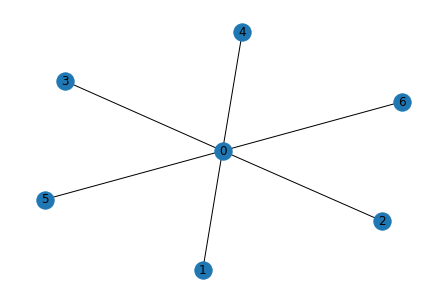

In [5]:
G = nx.star_graph(6)
nx.draw(G, with_labels=True)

In [6]:
L = nx.laplacian_matrix(G).toarray()
L

<class 'networkx.utils.decorators.argmap'> compilation 20:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


array([[ 6, -1, -1, -1, -1, -1, -1],
       [-1,  1,  0,  0,  0,  0,  0],
       [-1,  0,  1,  0,  0,  0,  0],
       [-1,  0,  0,  1,  0,  0,  0],
       [-1,  0,  0,  0,  1,  0,  0],
       [-1,  0,  0,  0,  0,  1,  0],
       [-1,  0,  0,  0,  0,  0,  1]])

Schur complement on vertices from $4$ to $6$

In [20]:
LSC1, LN1, LN1_1, LM1 = schurComplement(L.copy(), 4)
LSC1

array([[ 0.66666667, -0.33333333, -0.33333333],
       [-0.33333333,  0.66666667, -0.33333333],
       [-0.33333333, -0.33333333,  0.66666667]])

Schur complement on vertices from $3$ to $6$

In [21]:
LSC2, LN2, LN2_1, LM2 = schurComplement(L.copy(), 3)
LSC2

array([[ 0.75, -0.25, -0.25, -0.25],
       [-0.25,  0.75, -0.25, -0.25],
       [-0.25, -0.25,  0.75, -0.25],
       [-0.25, -0.25, -0.25,  0.75]])

Schur complement on vertices from $2$ to $6$

In [22]:
LSC3, LN3, LN3_1, LM3 = schurComplement(L.copy(), 2)
LSC3

array([[ 0.8, -0.2, -0.2, -0.2, -0.2],
       [-0.2,  0.8, -0.2, -0.2, -0.2],
       [-0.2, -0.2,  0.8, -0.2, -0.2],
       [-0.2, -0.2, -0.2,  0.8, -0.2],
       [-0.2, -0.2, -0.2, -0.2,  0.8]])

Adding vertex $3$ to $L_{SC1}$

In [27]:
u, v = compute_u_v(LN1.copy(), LN1_1.copy(), LM1, 3)

In [28]:
u, v

(array([-0.25, -0.25, -0.25,  0.75]),
 array([-0.33333333, -0.33333333, -0.33333333,  1.        ]))

In [30]:
L_new = add_zero_row_col(LSC1)
L_new

array([[ 0.66666667, -0.33333333, -0.33333333,  0.        ],
       [-0.33333333,  0.66666667, -0.33333333,  0.        ],
       [-0.33333333, -0.33333333,  0.66666667,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]])

In [32]:
L_new = L_new+np.outer(u,v)
L_new

array([[ 0.75, -0.25, -0.25, -0.25],
       [-0.25,  0.75, -0.25, -0.25],
       [-0.25, -0.25,  0.75, -0.25],
       [-0.25, -0.25, -0.25,  0.75]])

In [33]:
L_new = add_zero_row_col(L_new)
L_new

array([[ 0.75, -0.25, -0.25, -0.25,  0.  ],
       [-0.25,  0.75, -0.25, -0.25,  0.  ],
       [-0.25, -0.25,  0.75, -0.25,  0.  ],
       [-0.25, -0.25, -0.25,  0.75,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ]])

In [40]:
u, v = compute_u_v(LN1, LN1_1, LM1, 2)

In [41]:
u, v

(array([-0., -0., -0.,  0.]),
 array([-0.33333333, -0.33333333, -0.33333333,  1.        ]))

In [42]:
L

array([[ 6, -1, -1, -1, -1, -1, -1],
       [-1,  1,  0,  0,  0,  0,  0],
       [-1,  0,  1,  0,  0,  0,  0],
       [-1,  0,  0,  1,  0,  0,  0],
       [-1,  0,  0,  0,  1,  0,  0],
       [-1,  0,  0,  0,  0,  1,  0],
       [-1,  0,  0,  0,  0,  0,  1]])

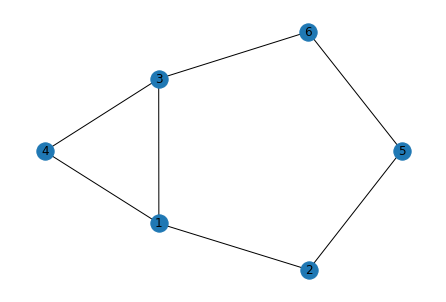

In [74]:
edge_list = [(1,2), (1,3), (1,4), (2,5), (3,4), (3,6),(5,6)]
G = nx.Graph(edge_list)
nx.draw(G, with_labels=True)

In [75]:
L = nx.laplacian_matrix(G).toarray()
L

<class 'networkx.utils.decorators.argmap'> compilation 20:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


array([[ 3, -1, -1, -1,  0,  0],
       [-1,  2,  0,  0, -1,  0],
       [-1,  0,  3, -1,  0, -1],
       [-1,  0, -1,  2,  0,  0],
       [ 0, -1,  0,  0,  2, -1],
       [ 0,  0, -1,  0, -1,  2]])

In [76]:
LSC, LN, LN_1, LM = schurComplement(L, 3)
LSC

array([[ 0.84615385, -0.30769231, -0.53846154],
       [-0.30769231,  1.38461538, -1.07692308],
       [-0.53846154, -1.07692308,  1.61538462]])

In [77]:
LN

array([[ 3, -1, -1],
       [-1,  2,  0],
       [-1,  0,  3]])

In [78]:
u, v = compute_u_v(LN, LN_1, LM, 1)

[-0.375 -0.125]
[-1  0]


In [79]:
u,v

(array([-0.5  , -1.   , -0.125,  1.625]),
 array([-0.30769231, -0.61538462, -0.07692308,  1.        ]))

In [80]:
np.outer(u,v)

array([[ 0.15384615,  0.30769231,  0.03846154, -0.5       ],
       [ 0.30769231,  0.61538462,  0.07692308, -1.        ],
       [ 0.03846154,  0.07692308,  0.00961538, -0.125     ],
       [-0.5       , -1.        , -0.125     ,  1.625     ]])

In [81]:
LSC

array([[ 0.84615385, -0.30769231, -0.53846154],
       [-0.30769231,  1.38461538, -1.07692308],
       [-0.53846154, -1.07692308,  1.61538462]])

In [82]:
np.outer(u,v)

array([[ 0.15384615,  0.30769231,  0.03846154, -0.5       ],
       [ 0.30769231,  0.61538462,  0.07692308, -1.        ],
       [ 0.03846154,  0.07692308,  0.00961538, -0.125     ],
       [-0.5       , -1.        , -0.125     ,  1.625     ]])

In [95]:
AUX = add_zero_row_col(LSC)
AUX

array([[ 0.84615385, -0.30769231, -0.53846154,  0.        ],
       [-0.30769231,  1.38461538, -1.07692308,  0.        ],
       [-0.53846154, -1.07692308,  1.61538462,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]])

In [96]:
B = np.outer(u,v)
B

array([[ 0.15384615,  0.30769231,  0.03846154, -0.5       ],
       [ 0.30769231,  0.61538462,  0.07692308, -1.        ],
       [ 0.03846154,  0.07692308,  0.00961538, -0.125     ],
       [-0.5       , -1.        , -0.125     ,  1.625     ]])

In [98]:
LSC1 = AUX+B


In [101]:
LSC1.round(3)

array([[ 1.   ,  0.   , -0.5  , -0.5  ],
       [-0.   ,  2.   , -1.   , -1.   ],
       [-0.5  , -1.   ,  1.625, -0.125],
       [-0.5  , -1.   , -0.125,  1.625]])

In [72]:
LSC2 = np.array([[13/8, -1/2, -1,-1/8],[-1/2, 1, 0, -1/2],[-1,0, 2, -1],[-1/8, -1/2, -1, 13/8]])
LSC2

array([[ 1.625, -0.5  , -1.   , -0.125],
       [-0.5  ,  1.   ,  0.   , -0.5  ],
       [-1.   ,  0.   ,  2.   , -1.   ],
       [-0.125, -0.5  , -1.   ,  1.625]])

In [5]:
import numpy as np

In [6]:
x=np.array([0.229519,-0.0238095,0.0514888,0])

In [12]:
x-x.mean()

array([ 0.16521943, -0.08810907, -0.01281077, -0.06429957])

In [4]:
A = np.array([[1, -1/2,0,0],[1/2,-1,1/2,0],[0, 1/2,-1,1/2],[0,0,-1/2,1]])
A

array([[ 1. , -0.5,  0. ,  0. ],
       [ 0.5, -1. ,  0.5,  0. ],
       [ 0. ,  0.5, -1. ,  0.5],
       [ 0. ,  0. , -0.5,  1. ]])

In [5]:
b = np.array([0,0,0,1/2])
b

array([0. , 0. , 0. , 0.5])

In [6]:
np.linalg.solve(A, b)

array([0.2, 0.4, 0.6, 0.8])

In [1]:
import networkx as nx

In [15]:
Grid = nx.grid_2d_graph(4,4)

In [18]:
Grid.edges()

EdgeView([((0, 0), (1, 0)), ((0, 0), (0, 1)), ((0, 1), (1, 1)), ((0, 1), (0, 2)), ((0, 2), (1, 2)), ((0, 2), (0, 3)), ((0, 3), (1, 3)), ((1, 0), (2, 0)), ((1, 0), (1, 1)), ((1, 1), (2, 1)), ((1, 1), (1, 2)), ((1, 2), (2, 2)), ((1, 2), (1, 3)), ((1, 3), (2, 3)), ((2, 0), (3, 0)), ((2, 0), (2, 1)), ((2, 1), (3, 1)), ((2, 1), (2, 2)), ((2, 2), (3, 2)), ((2, 2), (2, 3)), ((2, 3), (3, 3)), ((3, 0), (3, 1)), ((3, 1), (3, 2)), ((3, 2), (3, 3))])